<a href="https://colab.research.google.com/github/alabiyusuf/ml-technical-assessment-phso/blob/main/ML_Technical_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Environment Setup and Data Loading**

#### Environment Setup

In [86]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

#### Data Loading

In [87]:
# Extracting data from Excel assessment file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
# Importing Data

data_path = "/content/drive/MyDrive/Colab Notebooks/PHSO Technical Assessment/Technical Assessment.xlsx"

In [89]:
training_df = pd.read_excel(data_path, sheet_name="Training Dataset")
holdback_df = pd.read_excel(data_path, sheet_name="Holdback Dataset")

In [90]:
print("Training shape:", training_df.shape)
print("Holdback shape:", holdback_df.shape)


display(training_df.head())
display(holdback_df.head())



Training shape: (2000, 46)
Holdback shape: (500, 45)


,AdditionalCostsGBP,AdditionalTreatmentRequired,AgeBand,AnxietyReported,BereavedPerson,CaseComplexityScore,CaseCreatedDate,CaseReference,ComplaintCategory,DelayInResolutionDays,...,PrimaryVulnerability,PriorComplaintsRaised,RecoveryTimeMonths,RepeatedFailurePattern,RepeatFailuresCount,SafeguardingConcern,ServiceArea,SeverityScore,SleepDisruptionReported,VulnerabilityLevel
0,99.05,No,80+,No,No,7,2023-10-29,TRN-000001,Delay,95,...,Homelessness,0,3.0,No,0,No,Housing,3,No,Low
1,540.68,No,65-79,Yes,No,6,2024-12-29,TRN-000002,Clinical Decision,70,...,Mental Health,1,0.0,Yes,0,No,Mental Health,3,Yes,Low
2,99.40,No,35-49,Yes,No,7,2023-05-31,TRN-000003,Eligibility Decision,27,...,Financial Hardship,0,1.0,Yes,2,Yes,Benefits,3,No,High
3,180.32,Yes,18-34,No,No,6,2025-11-03,TRN-000004,Lost Information,53,...,Caring Responsibilities,0,0.0,Yes,3,No,Primary Care,1,No,Low
4,166.14,No,50-64,No,No,7,2025-11-27,TRN-000005,Communication,216,...,NaN,1,NaN,No,0,Yes,Taxation,2,Yes,High


,AdditionalCostsGBP,AdditionalTreatmentRequired,AgeBand,AnxietyReported,BereavedPerson,CaseComplexityScore,CaseCreatedDate,CaseReference,ComplaintCategory,DelayInResolutionDays,...,PredictedRemedyBand,PrimaryVulnerability,PriorComplaintsRaised,RecoveryTimeMonths,RepeatedFailurePattern,RepeatFailuresCount,SafeguardingConcern,ServiceArea,SleepDisruptionReported,VulnerabilityLevel
0,78.08,Yes,35-49,Yes,No,6,2023-01-20,HLD-000001,Administrative Error,199,...,D,Caring Responsibilities,1,5.0,No,1,No,Housing,No,High
1,353.70,Yes,35-49,Yes,No,4,2025-04-14,HLD-000002,Service Quality,110,...,D,Homelessness,0,4.0,No,0,No,Primary Care,No,Moderate
2,140.33,No,65-79,Yes,No,6,2024-12-26,HLD-000003,Delay,34,...,B,NaN,0,1.0,No,1,No,Acute Care,No,NaN
3,37.82,No,18-34,Yes,No,5,2026-05-05,HLD-000004,Incorrect Advice,93,...,C,Physical Health,1,1.0,No,1,Yes,Benefits,Yes,High
4,284.24,Yes,18-34,No,No,6,2025-03-03,HLD-000005,Incorrect Advice,192,...,C,Financial Hardship,0,4.0,Yes,2,No,Acute Care,No,High


In [91]:
display(training_df.describe())
display(holdback_df.describe())

,AdditionalCostsGBP,CaseComplexityScore,CaseCreatedDate,DelayInResolutionDays,DirectFinancialLossGBP,DurationAffectedDays,EstimatedImpactScore,EstimatedRiskScore,ExpectedFinancialRedressGBP,LostIncomeGBP,NumberOfDependentsAffected,NumberOfOrganisationsInvolved,NumberOfServiceFailures,PriorComplaintsRaised,RecoveryTimeMonths,RepeatFailuresCount,SeverityScore
count,1964.000000,2000.000000,2000,2000.00000,2000.000000,2000.000000,1969.000000,2000.000000,1944.000000,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000,1946.000000,2000.000000,2000.000000
mean,277.428875,5.659000,2024-09-27 01:30:00,102.00550,520.342250,102.988500,50.520061,48.407000,1765.162855,289.136790,1.043000,1.6340,2.237500,0.976500,3.275437,0.752000,2.753500
min,-250.000000,0.000000,2023-01-01 00:00:00,-8.00000,-100.000000,0.000000,0.000000,-3.000000,-50.000000,-500.000000,-1.000000,0.0000,0.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,122.942500,4.000000,2023-11-06 00:00:00,56.00000,112.835000,36.000000,31.000000,34.000000,349.955000,52.192500,0.000000,1.0000,1.000000,0.000000,1.000000,0.000000,1.000000
50%,195.875000,6.000000,2024-09-20 00:00:00,85.00000,239.635000,66.000000,47.000000,47.000000,720.960000,110.495000,1.000000,1.0000,2.000000,1.000000,2.000000,0.000000,3.000000
75%,311.015000,7.000000,2025-08-20 00:00:00,124.00000,496.175000,125.250000,68.000000,62.000000,1926.945000,239.270000,2.000000,2.0000,3.000000,1.000000,4.000000,1.000000,4.000000
max,62000.000000,12.000000,2026-06-30 00:00:00,2400.00000,125000.000000,3650.000000,108.000000,115.000000,90000.000000,130000.000000,12.000000,7.0000,24.000000,18.000000,144.000000,13.000000,6.000000
std,1410.848879,1.699754,NaN,92.98469,2889.966885,144.741205,24.733246,20.874655,3402.837423,2924.310012,1.041966,0.8351,1.543465,1.120525,5.698165,0.987413,1.484196


,AdditionalCostsGBP,CaseComplexityScore,CaseCreatedDate,DelayInResolutionDays,DirectFinancialLossGBP,DurationAffectedDays,EstimatedImpactScore,EstimatedRiskScore,ExpectedFinancialRedressGBP,LostIncomeGBP,NumberOfDependentsAffected,NumberOfOrganisationsInvolved,NumberOfServiceFailures,OmbudsmanInvestigationRequired,PriorComplaintsRaised,RecoveryTimeMonths,RepeatFailuresCount
count,492.000000,500.000000,500,500.00000,500.000000,500.000000,486.000000,500.000000,488.000000,500.000000,500.000000,500.000000,500.00000,0.0,500.000000,486.000000,500.000000
mean,369.407093,5.772000,2024-09-13 20:12:28.800000256,105.82800,694.238780,118.028000,49.598765,48.966000,1808.390820,461.099980,1.060000,1.668000,2.29600,NaN,0.974000,3.775720,0.816000
min,-250.000000,0.000000,2023-01-01 00:00:00,-8.00000,-100.000000,0.000000,0.000000,-3.000000,-50.000000,-500.000000,-1.000000,0.000000,0.00000,NaN,-1.000000,-1.000000,-1.000000
25%,120.377500,5.000000,2023-10-27 06:00:00,54.00000,105.225000,37.000000,29.000000,33.000000,343.750000,49.622500,0.000000,1.000000,1.00000,NaN,0.000000,1.000000,0.000000
50%,197.005000,6.000000,2024-09-23 12:00:00,85.00000,240.170000,70.500000,47.000000,48.000000,736.040000,117.665000,1.000000,1.000000,2.00000,NaN,1.000000,2.000000,1.000000
75%,302.725000,7.000000,2025-07-19 18:00:00,128.00000,506.752500,130.250000,68.750000,62.000000,1785.600000,234.377500,2.000000,2.000000,3.00000,NaN,1.000000,4.000000,1.000000
max,62000.000000,12.000000,2026-06-28 00:00:00,2400.00000,125000.000000,3650.000000,108.000000,115.000000,90000.000000,130000.000000,12.000000,7.000000,24.00000,NaN,18.000000,144.000000,13.000000
std,2791.776158,1.799581,NaN,129.90301,5605.129218,204.983393,25.316013,20.488152,4745.124744,5811.744681,1.100373,0.889583,1.84803,NaN,1.325458,8.219985,1.131683


### **Understanding Data & Quality Checks**

#### **Understanding the Dataset Structure**

In [92]:
print("Training dataset:")
print(f"Rows: {training_df.shape[0]}")
print(f"Columns: {training_df.shape[1]}")

print("\nHoldback dataset:")
print(f"Rows: {holdback_df.shape[0]}")
print(f"Columns: {holdback_df.shape[1]}")

Training dataset:
Rows: 2000
Columns: 46

Holdback dataset:
Rows: 500
Columns: 45


After inspecting the dataset via the excel sheet, the one-column difference is the `severityScore`, whic is the target in the training data and is not present in the holdback dataset

#### **Checking the Datatypes**

In [93]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   AdditionalCostsGBP              1964 non-null   float64       
 1   AdditionalTreatmentRequired     2000 non-null   object        
 2   AgeBand                         2000 non-null   object        
 3   AnxietyReported                 2000 non-null   object        
 4   BereavedPerson                  2000 non-null   object        
 5   CaseComplexityScore             2000 non-null   int64         
 6   CaseCreatedDate                 2000 non-null   datetime64[ns]
 7   CaseReference                   2000 non-null   object        
 8   ComplaintCategory               2000 non-null   object        
 9   DelayInResolutionDays           2000 non-null   int64         
 10  DepressionReported              2000 non-null   object        
 11  Dete

In [94]:
holdback_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   AdditionalCostsGBP              492 non-null    float64       
 1   AdditionalTreatmentRequired     500 non-null    object        
 2   AgeBand                         500 non-null    object        
 3   AnxietyReported                 500 non-null    object        
 4   BereavedPerson                  500 non-null    object        
 5   CaseComplexityScore             500 non-null    int64         
 6   CaseCreatedDate                 500 non-null    datetime64[ns]
 7   CaseReference                   500 non-null    object        
 8   ComplaintCategory               500 non-null    object        
 9   DelayInResolutionDays           500 non-null    int64         
 10  DepressionReported              500 non-null    object        
 11  Deteri

Checking the dataset types and core informaiton because I need to identify the numerical and categorical variables, mssing values or any data that might have been interpreted incorrectly.

#### **Missing Values**

In [95]:
training_missing_values = (
    training_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

training_missing_values[training_missing_values > 0]

,0
FailureTypeSecondary,925
PrimaryVulnerability,505
VulnerabilityLevel,404
PhysicalImpactLevel,336
Jurisdiction,112
EvidenceStrength,58
ExpectedFinancialRedressGBP,56
RecoveryTimeMonths,54
OrganisationType,38
AdditionalCostsGBP,36


In [96]:
holdback_missing_values = (
    holdback_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

holdback_missing_values[holdback_missing_values > 0]

,0
OmbudsmanInvestigationRequired,500
FailureTypeSecondary,245
PrimaryVulnerability,144
VulnerabilityLevel,118
PhysicalImpactLevel,82
Jurisdiction,34
EvidenceStrength,16
EmotionalImpactLevel,14
EstimatedImpactScore,14
RecoveryTimeMonths,14


#### **Duplicate Records**

In [97]:
print("Duplicate training rows:", training_df.duplicated().sum())
print("Duplicate holdback rows:", holdback_df.duplicated().sum())

Duplicate training rows: 0
Duplicate holdback rows: 0


In [98]:
print(
    "Duplicate training CaseReferences:",
    training_df["CaseReference"].duplicated().sum()
)

print(
    "Duplicate holdback CaseReferences:",
    holdback_df["CaseReference"].duplicated().sum()
)

Duplicate training CaseReferences: 0
Duplicate holdback CaseReferences: 0


#### **Target Distribution**

In [99]:
target_distribution = (
    training_df["SeverityScore"]
    .value_counts()
    .sort_index()
)

print(target_distribution)

print("\nPercentage distribution:")
print(
    (target_distribution / len(training_df) * 100)
    .round(2)
)

SeverityScore
1    504
2    491
3    404
4    297
5    203
6    101
Name: count, dtype: int64

Percentage distribution:
SeverityScore
1    25.20
2    24.55
3    20.20
4    14.85
5    10.15
6     5.05
Name: count, dtype: float64


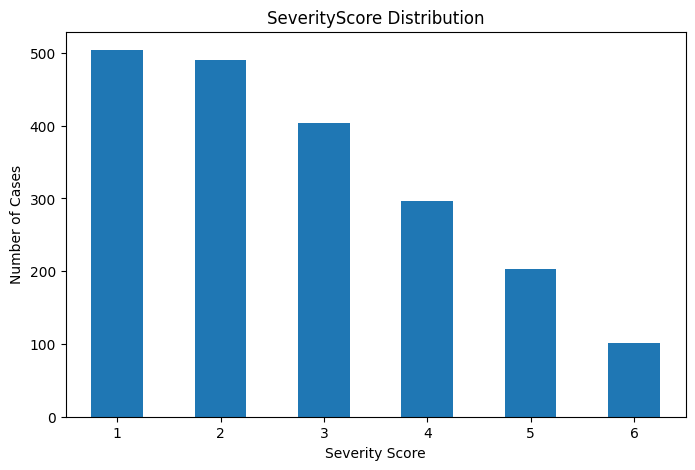

In [100]:
target_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("SeverityScore Distribution")
plt.xlabel("Severity Score")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)
plt.show()

#### **Numerical Summary**

In [101]:
training_df.describe().T

,count,mean,min,25%,50%,75%,max,std
AdditionalCostsGBP,1964.0,277.428875,-250.0,122.9425,195.875,311.015,62000.0,1410.848879
CaseComplexityScore,2000.0,5.659,0.0,4.0,6.0,7.0,12.0,1.699754
CaseCreatedDate,2000,2024-09-27 01:30:00,2023-01-01 00:00:00,2023-11-06 00:00:00,2024-09-20 00:00:00,2025-08-20 00:00:00,2026-06-30 00:00:00,NaN
DelayInResolutionDays,2000.0,102.0055,-8.0,56.0,85.0,124.0,2400.0,92.98469
DirectFinancialLossGBP,2000.0,520.34225,-100.0,112.835,239.635,496.175,125000.0,2889.966885
DurationAffectedDays,2000.0,102.9885,0.0,36.0,66.0,125.25,3650.0,144.741205
EstimatedImpactScore,1969.0,50.520061,0.0,31.0,47.0,68.0,108.0,24.733246
EstimatedRiskScore,2000.0,48.407,-3.0,34.0,47.0,62.0,115.0,20.874655
ExpectedFinancialRedressGBP,1944.0,1765.162855,-50.0,349.955,720.96,1926.945,90000.0,3402.837423
LostIncomeGBP,2000.0,289.13679,-500.0,52.1925,110.495,239.27,130000.0,2924.310012


#### **Categorical Variables**

In [102]:
categorical_columns = training_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_columns

['AdditionalTreatmentRequired',
 'AgeBand',
 'AnxietyReported',
 'BereavedPerson',
 'CaseReference',
 'ComplaintCategory',
 'DepressionReported',
 'DeteriorationInHealth',
 'EmotionalImpactLevel',
 'EscalatedInternally',
 'EvidenceStrength',
 'FailureTypePrimary',
 'FailureTypeSecondary',
 'ImpactOnRelationships',
 'InvestigationRoute',
 'Jurisdiction',
 'LegalChallengePotential',
 'LongTermImpactFlag',
 'MultipleComplaintThemes',
 'OmbudsmanInvestigationRequired',
 'OrganisationType',
 'PhysicalImpactLevel',
 'PredictedRemedyBand',
 'PrimaryVulnerability',
 'RepeatedFailurePattern',
 'SafeguardingConcern',
 'ServiceArea',
 'SleepDisruptionReported',
 'VulnerabilityLevel']

In [103]:
for col in categorical_columns:
    print(f"\n-- {col} --")
    print(training_df[col].value_counts(dropna=False).head(10))


-- AdditionalTreatmentRequired --
AdditionalTreatmentRequired
No     1188
Yes     812
Name: count, dtype: int64

-- AgeBand --
AgeBand
50-64       482
35-49       450
18-34       389
65-79       386
80+         210
Under 18     83
Name: count, dtype: int64

-- AnxietyReported --
AnxietyReported
No     1016
Yes     984
Name: count, dtype: int64

-- BereavedPerson --
BereavedPerson
No     1939
Yes      61
Name: count, dtype: int64

-- CaseReference --
CaseReference
TRN-001984    1
TRN-001983    1
TRN-001982    1
TRN-001981    1
TRN-001980    1
TRN-001979    1
TRN-001978    1
TRN-001977    1
TRN-001976    1
TRN-001975    1
Name: count, dtype: int64

-- ComplaintCategory --
ComplaintCategory
Delay                   377
Clinical Decision       330
Communication           322
Administrative Error    285
Service Quality         258
Incorrect Advice        222
Lost Information        106
Eligibility Decision    100
Name: count, dtype: int64

-- DepressionReported --
DepressionReported
No     

### **Leakage & Feature Availability**

#### **Comparing training and holdback columns**

In [104]:
training_features = set(training_df.columns) - {"SeverityScore"}
holdback_features = set(holdback_df.columns)

print("Features in training but not holdback:")
print(sorted(training_features - holdback_features))

print("\nFeatures in holdback but not training:")
print(sorted(holdback_features - training_features))

Features in training but not holdback:
[]

Features in holdback but not training:
[]


#### **Checking for Suspicious Variables**

In [105]:
suspicious_features = [
    "OmbudsmanInvestigationRequired",
    "PredictedRemedyBand",
    "EstimatedImpactScore",
    "EstimatedRiskScore",
    "ExpectedFinancialRedressGBP",
    "InvestigationRoute"
]

for col in suspicious_features:
    print(f"\n--- {col} ---")
    print(training_df.groupby("SeverityScore")[col].value_counts(normalize=True).round(3))


--- OmbudsmanInvestigationRequired ---
SeverityScore  OmbudsmanInvestigationRequired
1              No                                1.0
2              No                                1.0
3              No                                1.0
4              Yes                               1.0
5              Yes                               1.0
6              Yes                               1.0
Name: proportion, dtype: float64

--- PredictedRemedyBand ---
SeverityScore  PredictedRemedyBand
1              A                      0.510
               B                      0.458
               C                      0.032
2              B                      0.674
               C                      0.224
               A                      0.098
               D                      0.004
3              C                      0.572
               B                      0.334
               D                      0.074
               A                      0.020
4              

#### **Checking for the key numerical relationships**

In [106]:
numeric_features = training_df.select_dtypes(include=["number"]).columns

correlations = (
    training_df[numeric_features]
    .corr(method="spearman")["SeverityScore"]
    .drop("SeverityScore")
    .sort_values(ascending=False)
)

correlations

,SeverityScore
EstimatedImpactScore,0.939055
ExpectedFinancialRedressGBP,0.853639
EstimatedRiskScore,0.791958
RecoveryTimeMonths,0.659124
DurationAffectedDays,0.530262
DelayInResolutionDays,0.334598
LostIncomeGBP,0.329610
DirectFinancialLossGBP,0.242569
NumberOfServiceFailures,0.237205
PriorComplaintsRaised,0.176288


#### **Investigating**

##### Investigating `OmbudsmanInvestigationRequired`

In [107]:
pd.crosstab(
    training_df["OmbudsmanInvestigationRequired"],
    training_df["SeverityScore"],
    normalize="index"
).round(3)

SeverityScore,1,2,3,4,5,6
OmbudsmanInvestigationRequired,,,,,,
No,0.36,0.351,0.289,0.000,0.000,0.000
Yes,0.00,0.000,0.000,0.494,0.338,0.168


In [108]:
training_df["HighSeverity"] = (
    training_df["SeverityScore"] >= 4
).astype(int)

pd.crosstab(
    training_df["OmbudsmanInvestigationRequired"],
    training_df["HighSeverity"],
    normalize="index"
).round(3)

HighSeverity,0,1
OmbudsmanInvestigationRequired,,
No,1.0,0.0
Yes,0.0,1.0


##### Investigating `PredictedRemedyBand`

In [109]:
pd.crosstab(
    training_df["PredictedRemedyBand"],
    training_df["SeverityScore"],
    normalize="index"
).round(3)

SeverityScore,1,2,3,4,5,6
PredictedRemedyBand,,,,,,
A,0.821,0.153,0.026,0.000,0.000,0.000
B,0.325,0.466,0.190,0.018,0.000,0.000
C,0.027,0.183,0.384,0.331,0.071,0.005
D,0.000,0.007,0.103,0.282,0.460,0.148
E,0.000,0.000,0.000,0.039,0.338,0.623
F,0.000,0.000,0.000,0.000,0.000,1.000


In [110]:
pd.crosstab(
    training_df["PredictedRemedyBand"],
    training_df["HighSeverity"],
    normalize="index"
).round(3)

HighSeverity,0,1
PredictedRemedyBand,,
A,1.000,0.000
B,0.982,0.018
C,0.593,0.407
D,0.110,0.890
E,0.000,1.000
F,0.000,1.000


#### **Check other categorical variables**

In [111]:
for col in ["InvestigationRoute", "PredictedRemedyBand"]:
    print(f"\n===== {col} =====")

    summary = pd.crosstab(
        training_df[col],
        training_df["SeverityScore"],
        normalize="index"
    ).round(3)

    display(summary)


===== InvestigationRoute =====


SeverityScore,1,2,3,4,5,6
InvestigationRoute,,,,,,
Escalated,0.271,0.275,0.174,0.147,0.106,0.028
Fast Track,0.259,0.224,0.178,0.167,0.112,0.060
Standard,0.248,0.246,0.212,0.144,0.098,0.052



===== PredictedRemedyBand =====


SeverityScore,1,2,3,4,5,6
PredictedRemedyBand,,,,,,
A,0.821,0.153,0.026,0.000,0.000,0.000
B,0.325,0.466,0.190,0.018,0.000,0.000
C,0.027,0.183,0.384,0.331,0.071,0.005
D,0.000,0.007,0.103,0.282,0.460,0.148
E,0.000,0.000,0.000,0.039,0.338,0.623
F,0.000,0.000,0.000,0.000,0.000,1.000


#### **Check Data Range**

In [112]:
print("Earliest case:", training_df["CaseCreatedDate"].min())
print("Latest case:", training_df["CaseCreatedDate"].max())

print("\nHoldback earliest case:", holdback_df["CaseCreatedDate"].min())
print("Holdback latest case:", holdback_df["CaseCreatedDate"].max())

Earliest case: 2023-01-01 00:00:00
Latest case: 2026-06-30 00:00:00

Holdback earliest case: 2023-01-01 00:00:00
Holdback latest case: 2026-06-28 00:00:00


### **Feature Availability and Modelling Decisions**

#### Initial modelling decision

The following variables will be excluded from the initial model:

- `SeverityScore` because it is the target.
- `CaseReference` because it is an identifier.
- `OmbudsmanInvestigationRequired` because it is unavailable in the holdback dataset and directly corresponds to the 1–3 versus 4–6 investigation decision.

The remaining candidate features will be retained initially where they are available in both datasets. Their contribution will be assessed through model comparison and feature importance, while recognising that highly predictive variables may represent information generated later in the complaint process.

A sensitivity comparison will be used where necessary to assess whether excluding potentially downstream variables materially changes model performance.

In [113]:
TARGET = "SeverityScore"
ID_COL = "CaseReference"

print("Target:", TARGET)
print("ID column:", ID_COL)

Target: SeverityScore
ID column: CaseReference


In [114]:
candidate_features = [
    "PredictedRemedyBand",
    "EstimatedImpactScore",
    "EstimatedRiskScore",
    "ExpectedFinancialRedressGBP",
    "InvestigationRoute"
]

availability_check = pd.DataFrame({
    "Training missing %": (
        training_df[candidate_features].isna().mean() * 100
    ).round(1),
    "Holdback missing %": (
        holdback_df[candidate_features].isna().mean() * 100
    ).round(1),
    "Training unique values": [
        training_df[col].nunique(dropna=True)
        for col in candidate_features
    ],
    "Holdback unique values": [
        holdback_df[col].nunique(dropna=True)
        for col in candidate_features
    ]
})

display(availability_check)

,Training missing %,Holdback missing %,Training unique values,Holdback unique values
PredictedRemedyBand,0.0,0.0,6,6
EstimatedImpactScore,1.6,2.8,101,95
EstimatedRiskScore,0.0,0.0,102,91
ExpectedFinancialRedressGBP,2.8,2.4,1935,488
InvestigationRoute,0.0,0.0,3,3


#### **Numeric Features against Severity**

Relationship between candidate features and severity

The strongest candidate variables are examined against `SeverityScore` to understand whether their predictive relationship is plausible and whether they may represent downstream decisions.

In [115]:
candidate_numeric = [
    "EstimatedImpactScore",
    "EstimatedRiskScore",
    "ExpectedFinancialRedressGBP"
]

candidate_summary = training_df[
    candidate_numeric + [TARGET]
].groupby(TARGET).mean().round(2)

display(candidate_summary)

,EstimatedImpactScore,EstimatedRiskScore,ExpectedFinancialRedressGBP
SeverityScore,,,
1,22.33,27.64,303.20
2,39.15,41.63,597.64
3,54.79,51.31,1172.29
4,70.84,61.46,2502.50
5,86.14,73.00,4608.26
6,98.24,85.57,9212.86


In [116]:
remedy_summary = pd.crosstab(
    training_df["PredictedRemedyBand"],
    training_df[TARGET],
    normalize="index"
).round(3)

display(remedy_summary)

SeverityScore,1,2,3,4,5,6
PredictedRemedyBand,,,,,,
A,0.821,0.153,0.026,0.000,0.000,0.000
B,0.325,0.466,0.190,0.018,0.000,0.000
C,0.027,0.183,0.384,0.331,0.071,0.005
D,0.000,0.007,0.103,0.282,0.460,0.148
E,0.000,0.000,0.000,0.039,0.338,0.623
F,0.000,0.000,0.000,0.000,0.000,1.000


In [117]:
EXCLUDED_FEATURES = [
    TARGET,
    ID_COL,
    "OmbudsmanInvestigationRequired"
]

print("Excluded features:")
for feature in EXCLUDED_FEATURES:
    print("-", feature)

Excluded features:
- SeverityScore
- CaseReference
- OmbudsmanInvestigationRequired


In [118]:
# Create clean modelling copies from the original datasets
train = training_df.copy()
holdback = holdback_df.copy()

# Remove exploratory columns if they exist
exploratory_columns = ["HighSeverity"]

train = train.drop(columns=exploratory_columns, errors="ignore")
holdback = holdback.drop(columns=exploratory_columns, errors="ignore")

print("Training shape:", train.shape)
print("Holdback shape:", holdback.shape)

Training shape: (2000, 46)
Holdback shape: (500, 45)


In [119]:
print("Training columns:")
print(train.columns.tolist())

print("\nHoldback columns:")
print(holdback.columns.tolist())

Training columns:
['AdditionalCostsGBP', 'AdditionalTreatmentRequired', 'AgeBand', 'AnxietyReported', 'BereavedPerson', 'CaseComplexityScore', 'CaseCreatedDate', 'CaseReference', 'ComplaintCategory', 'DelayInResolutionDays', 'DepressionReported', 'DeteriorationInHealth', 'DirectFinancialLossGBP', 'DurationAffectedDays', 'EmotionalImpactLevel', 'EscalatedInternally', 'EstimatedImpactScore', 'EstimatedRiskScore', 'EvidenceStrength', 'ExpectedFinancialRedressGBP', 'FailureTypePrimary', 'FailureTypeSecondary', 'ImpactOnRelationships', 'InvestigationRoute', 'Jurisdiction', 'LegalChallengePotential', 'LongTermImpactFlag', 'LostIncomeGBP', 'MultipleComplaintThemes', 'NumberOfDependentsAffected', 'NumberOfOrganisationsInvolved', 'NumberOfServiceFailures', 'OmbudsmanInvestigationRequired', 'OrganisationType', 'PhysicalImpactLevel', 'PredictedRemedyBand', 'PrimaryVulnerability', 'PriorComplaintsRaised', 'RecoveryTimeMonths', 'RepeatedFailurePattern', 'RepeatFailuresCount', 'SafeguardingConcern',

In [120]:
for df in [train, holdback]:
    df["CaseCreatedDate"] = pd.to_datetime(
        df["CaseCreatedDate"],
        errors="coerce"
    )

    df["CaseCreatedYear"] = df["CaseCreatedDate"].dt.year
    df["CaseCreatedMonth"] = df["CaseCreatedDate"].dt.month
    df["CaseCreatedDayOfWeek"] = df["CaseCreatedDate"].dt.dayofweek

    df.drop(columns=["CaseCreatedDate"], inplace=True)

In [121]:
print(train[[
    "CaseCreatedYear",
    "CaseCreatedMonth",
    "CaseCreatedDayOfWeek"
]].head())

   CaseCreatedYear  CaseCreatedMonth  CaseCreatedDayOfWeek
0             2023                10                     6
1             2024                12                     6
2             2023                 5                     2
3             2025                11                     0
4             2025                11                     3


In [122]:
print(train[TARGET].value_counts().sort_index())

SeverityScore
1    504
2    491
3    404
4    297
5    203
6    101
Name: count, dtype: int64


In [123]:
print(
    "Number of severity classes:",
    train[TARGET].nunique()
)

Number of severity classes: 6


### **Data Preparation**

#### Defining Target Features

In [124]:
# Define target and identifier

TARGET = "SeverityScore"
ID_COL = "CaseReference"

X = train.drop(columns=[TARGET])
y = train[TARGET]

X_holdback = holdback.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Holdback shape:", X_holdback.shape)

X shape: (2000, 47)
y shape: (2000,)
Holdback shape: (500, 47)


In [125]:
# Remove identifier and unavailable/leaky feature

EXCLUDED_FEATURES = [
    "CaseReference",
    "OmbudsmanInvestigationRequired"
]

X = X.drop(columns=EXCLUDED_FEATURES, errors="ignore")
X_holdback = X_holdback.drop(columns=EXCLUDED_FEATURES, errors="ignore")

print("X shape after exclusions:", X.shape)
print("Holdback shape after exclusions:", X_holdback.shape)

X shape after exclusions: (2000, 45)
Holdback shape after exclusions: (500, 45)


#### **Feature Engineering**

`CaseCreatedDate` is converted into separate year, month and day-of-week features. The original date is then removed because the raw date is not directly suitable for modelling.

In [126]:
print("X shape:", X.shape)
print("Holdback shape:", X_holdback.shape)

display(
    X[
        [
            "CaseCreatedYear",
            "CaseCreatedMonth",
            "CaseCreatedDayOfWeek"
        ]
    ].head()
)

X shape: (2000, 45)
Holdback shape: (500, 45)


,CaseCreatedYear,CaseCreatedMonth,CaseCreatedDayOfWeek
0,2023,10,6
1,2024,12,6
2,2023,5,2
3,2025,11,0
4,2025,11,3


#### Identifying Numeric and Categorical Features

In [127]:
numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 18
Categorical features: 27


In [128]:
print("\nCategorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)


Categorical features:
['AdditionalTreatmentRequired', 'AgeBand', 'AnxietyReported', 'BereavedPerson', 'ComplaintCategory', 'DepressionReported', 'DeteriorationInHealth', 'EmotionalImpactLevel', 'EscalatedInternally', 'EvidenceStrength', 'FailureTypePrimary', 'FailureTypeSecondary', 'ImpactOnRelationships', 'InvestigationRoute', 'Jurisdiction', 'LegalChallengePotential', 'LongTermImpactFlag', 'MultipleComplaintThemes', 'OrganisationType', 'PhysicalImpactLevel', 'PredictedRemedyBand', 'PrimaryVulnerability', 'RepeatedFailurePattern', 'SafeguardingConcern', 'ServiceArea', 'SleepDisruptionReported', 'VulnerabilityLevel']

Numeric features:
['AdditionalCostsGBP', 'CaseComplexityScore', 'DelayInResolutionDays', 'DirectFinancialLossGBP', 'DurationAffectedDays', 'EstimatedImpactScore', 'EstimatedRiskScore', 'ExpectedFinancialRedressGBP', 'LostIncomeGBP', 'NumberOfDependentsAffected', 'NumberOfOrganisationsInvolved', 'NumberOfServiceFailures', 'PriorComplaintsRaised', 'RecoveryTimeMonths', 'Re

#### Checking missing values before building the pipleline

In [129]:
missing = (
    X.isna()
     .sum()
     .to_frame("Missing")
)

missing["Missing %"] = (
    missing["Missing"] / len(X) * 100
).round(2)

display(
    missing[missing["Missing"] > 0]
    .sort_values("Missing %", ascending=False)
)

,Missing,Missing %
FailureTypeSecondary,925,46.25
PrimaryVulnerability,505,25.25
VulnerabilityLevel,404,20.20
PhysicalImpactLevel,336,16.80
Jurisdiction,112,5.60
EvidenceStrength,58,2.90
ExpectedFinancialRedressGBP,56,2.80
RecoveryTimeMonths,54,2.70
OrganisationType,38,1.90
AdditionalCostsGBP,36,1.80


#### Preprocessing

In [130]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [131]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [132]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [133]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [134]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['AdditionalCostsGBP', 'CaseComplexityScore',
                                  'DelayInResolutionDays',
                                  'DirectFinancialLossGBP',
                                  'DurationAffectedDays',
                                  'EstimatedImpactScore', 'EstimatedRiskScore',
                                  'ExpectedFinancialRedressGBP',
                                  'LostIncomeGBP', 'NumberOfDepen...
                                  'FailureTypeSecondary',
                                  'ImpactOnRelationships', 'InvestigationRoute',
                                  'Jurisdiction', 'LegalChallengePotential',
                                  'LongTermImpa

#### Train/Validation

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_valid.shape)

Training set: (1600, 45)
Validation set: (400, 45)
Training target: (1600,)
Validation target: (400,)


In [136]:
comparison = pd.DataFrame({
    "Full": y.value_counts(normalize=True).sort_index(),
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Validation": y_valid.value_counts(normalize=True).sort_index()
})

display((comparison * 100).round(2))

,Full,Train,Validation
SeverityScore,,,
1,25.20,25.19,25.25
2,24.55,24.56,24.50
3,20.20,20.19,20.25
4,14.85,14.88,14.75
5,10.15,10.12,10.25
6,5.05,5.06,5.00


Train-Validation Split

The data was split into 80% training and 20% validation sets using stratification on `SeverityScore`. This preserves the distribution of all six severity classes across both datasets and provides a representative validation set for model evaluation.

The resulting datasets contain 1,600 training cases and 400 validation cases. The class proportions remain closely aligned with the full dataset, including the less frequent higher-severity cases.

In [137]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

### **Baseline Model**

A dummy classifier is used as a benchmark before evaluating machine learning models. It always predicts the most frequent severity class, allowing model performance to be compared against a simple non-learning baseline.

In [138]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_valid)

print("Baseline Accuracy:", round(accuracy_score(y_valid, baseline_pred), 4))
print("Baseline Macro F1:", round(f1_score(y_valid, baseline_pred, average="macro"), 4))
print("Baseline Weighted F1:", round(f1_score(y_valid, baseline_pred, average="weighted"), 4))

print("\nClassification Report:")
print(classification_report(y_valid, baseline_pred, zero_division=0))

Baseline Accuracy: 0.2525
Baseline Macro F1: 0.0672
Baseline Weighted F1: 0.1018

Classification Report:
              precision    recall  f1-score   support

           1       0.25      1.00      0.40       101
           2       0.00      0.00      0.00        98
           3       0.00      0.00      0.00        81
           4       0.00      0.00      0.00        59
           5       0.00      0.00      0.00        41
           6       0.00      0.00      0.00        20

    accuracy                           0.25       400
   macro avg       0.04      0.17      0.07       400
weighted avg       0.06      0.25      0.10       400



In [139]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_valid)

print("Logistic Regression Accuracy:",
      round(accuracy_score(y_valid, logistic_pred), 4))

print("Logistic Regression Macro F1:",
      round(f1_score(y_valid, logistic_pred, average="macro"), 4))

print("Logistic Regression Weighted F1:",
      round(f1_score(y_valid, logistic_pred, average="weighted"), 4))

Logistic Regression Accuracy: 0.7425
Logistic Regression Macro F1: 0.7165
Logistic Regression Weighted F1: 0.741


**Logistic Regression Evaluation**

Overall accuracy and F1 scores provide a useful summary of model performance, but they do not fully capture the business risk of misclassifying severe cases.

Because severity scores 4–6 are progressed for further investigation, the model is also evaluated on its ability to identify these higher-severity cases.

In [140]:
print("Logistic Regression Classification Report")
print(
    classification_report(
        y_valid,
        logistic_pred,
        labels=[1, 2, 3, 4, 5, 6],
        zero_division=0
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

           1       0.90      0.96      0.93       101
           2       0.77      0.69      0.73        98
           3       0.62      0.63      0.63        81
           4       0.67      0.68      0.67        59
           5       0.66      0.66      0.66        41
           6       0.67      0.70      0.68        20

    accuracy                           0.74       400
   macro avg       0.71      0.72      0.72       400
weighted avg       0.74      0.74      0.74       400



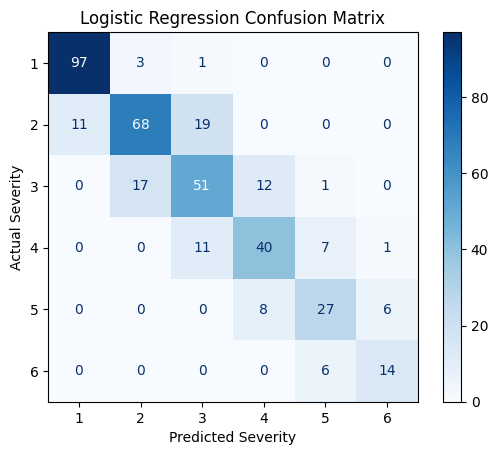

In [141]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    logistic_pred,
    labels=[1, 2, 3, 4, 5, 6],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")
plt.show()

In [142]:
actual_investigation = (y_valid >= 4).astype(int)
predicted_investigation = (logistic_pred >= 4).astype(int)

print("Investigation Decision Metrics")
print(
    classification_report(
        actual_investigation,
        predicted_investigation,
        target_names=["Not Progressed (1-3)", "Progressed (4-6)"],
        zero_division=0
    )
)

Investigation Decision Metrics
                      precision    recall  f1-score   support

Not Progressed (1-3)       0.96      0.95      0.96       280
    Progressed (4-6)       0.89      0.91      0.90       120

            accuracy                           0.94       400
           macro avg       0.93      0.93      0.93       400
        weighted avg       0.94      0.94      0.94       400



In [143]:
from sklearn.metrics import recall_score

investigation_recall = recall_score(
    actual_investigation,
    predicted_investigation
)

print(
    "Recall for cases requiring further investigation:",
    round(investigation_recall, 4)
)

Recall for cases requiring further investigation: 0.9083


**Model 2: Random Forest**

Random Forest is evaluated as a non-linear tree-based model. Unlike Logistic Regression, it can capture interactions and non-linear relationships between complaint characteristics and severity.

The model will be evaluated using both six-class performance metrics and the business-focused investigation recall for severity scores 4–6.

In [144]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_valid)

print("Random Forest Accuracy:",
      round(accuracy_score(y_valid, rf_pred), 4))

print("Random Forest Macro F1:",
      round(f1_score(y_valid, rf_pred, average="macro"), 4))

print("Random Forest Weighted F1:",
      round(f1_score(y_valid, rf_pred, average="weighted"), 4))

Random Forest Accuracy: 0.775
Random Forest Macro F1: 0.7796
Random Forest Weighted F1: 0.773


In [145]:
actual_investigation = (y_valid >= 4).astype(int)
rf_investigation = (rf_pred >= 4).astype(int)

print("Random Forest Investigation Decision Metrics")
print(
    classification_report(
        actual_investigation,
        rf_investigation,
        target_names=["Not Progressed (1-3)", "Progressed (4-6)"],
        zero_division=0
    )
)

rf_investigation_recall = recall_score(
    actual_investigation,
    rf_investigation
)

print(
    "Recall for cases requiring further investigation:",
    round(rf_investigation_recall, 4)
)

Random Forest Investigation Decision Metrics
                      precision    recall  f1-score   support

Not Progressed (1-3)       0.96      0.96      0.96       280
    Progressed (4-6)       0.92      0.91      0.91       120

            accuracy                           0.95       400
           macro avg       0.94      0.94      0.94       400
        weighted avg       0.95      0.95      0.95       400

Recall for cases requiring further investigation: 0.9083


**Model 3: HistGradientBoosting**

HistGradientBoosting is evaluated as a boosting-based model capable of learning non-linear relationships and interactions between features.

Its performance will be compared with Logistic Regression and Random Forest using both six-class classification metrics and the business-focused investigation recall.

In [146]:
from sklearn.ensemble import HistGradientBoostingClassifier

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

gb_pred = gradient_boosting_model.predict(X_valid)

print(
    "HistGradientBoosting Accuracy:",
    round(accuracy_score(y_valid, gb_pred), 4)
)

print(
    "HistGradientBoosting Macro F1:",
    round(f1_score(y_valid, gb_pred, average="macro"), 4)
)

print(
    "HistGradientBoosting Weighted F1:",
    round(f1_score(y_valid, gb_pred, average="weighted"), 4)
)

HistGradientBoosting Accuracy: 0.7525
HistGradientBoosting Macro F1: 0.7583
HistGradientBoosting Weighted F1: 0.7525


In [147]:
actual_investigation = (y_valid >= 4).astype(int)
gb_investigation = (gb_pred >= 4).astype(int)

print("HistGradientBoosting Investigation Decision Metrics")

print(
    classification_report(
        actual_investigation,
        gb_investigation,
        target_names=[
            "Not Progressed (1-3)",
            "Progressed (4-6)"
        ],
        zero_division=0
    )
)

gb_investigation_recall = recall_score(
    actual_investigation,
    gb_investigation
)

print(
    "Recall for cases requiring further investigation:",
    round(gb_investigation_recall, 4)
)

HistGradientBoosting Investigation Decision Metrics
                      precision    recall  f1-score   support

Not Progressed (1-3)       0.96      0.96      0.96       280
    Progressed (4-6)       0.90      0.91      0.90       120

            accuracy                           0.94       400
           macro avg       0.93      0.93      0.93       400
        weighted avg       0.94      0.94      0.94       400

Recall for cases requiring further investigation: 0.9083


### **Model Comparison**

The three candidate models are compared using overall accuracy, macro F1, weighted F1 and recall for cases requiring further investigation.

Macro F1 is given particular consideration because the six severity classes are imbalanced, while investigation recall reflects the operational requirement to identify cases with severity scores of 4–6.

In [148]:
model_results = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "Accuracy": [
        accuracy_score(y_valid, baseline_pred),
        accuracy_score(y_valid, logistic_pred),
        accuracy_score(y_valid, rf_pred),
        accuracy_score(y_valid, gb_pred)
    ],
    "Macro F1": [
        f1_score(y_valid, baseline_pred, average="macro"),
        f1_score(y_valid, logistic_pred, average="macro"),
        f1_score(y_valid, rf_pred, average="macro"),
        f1_score(y_valid, gb_pred, average="macro")
    ],
    "Weighted F1": [
        f1_score(y_valid, baseline_pred, average="weighted"),
        f1_score(y_valid, logistic_pred, average="weighted"),
        f1_score(y_valid, rf_pred, average="weighted"),
        f1_score(y_valid, gb_pred, average="weighted")
    ],
    "Investigation Recall": [
        0.0,
        investigation_recall,
        rf_investigation_recall,
        gb_investigation_recall
    ]
})

model_results = model_results.round(4)

display(model_results)

,Model,Accuracy,Macro F1,Weighted F1,Investigation Recall
0,Dummy Baseline,0.2525,0.0672,0.1018,0.0000
1,Logistic Regression,0.7425,0.7165,0.7410,0.9083
2,Random Forest,0.7750,0.7796,0.7730,0.9083
3,HistGradientBoosting,0.7525,0.7583,0.7525,0.9083


In [149]:
print("Random Forest Classification Report")
print(
    classification_report(
        y_valid,
        rf_pred,
        labels=[1, 2, 3, 4, 5, 6],
        zero_division=0
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

           1       0.87      0.98      0.92       101
           2       0.80      0.68      0.74        98
           3       0.67      0.69      0.68        81
           4       0.66      0.69      0.68        59
           5       0.75      0.73      0.74        41
           6       1.00      0.85      0.92        20

    accuracy                           0.78       400
   macro avg       0.79      0.77      0.78       400
weighted avg       0.78      0.78      0.77       400



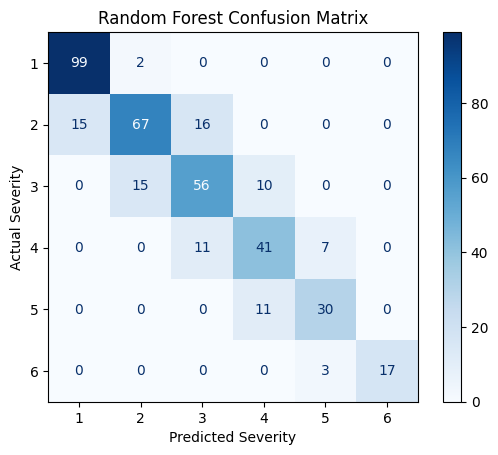

In [150]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    rf_pred,
    labels=[1, 2, 3, 4, 5, 6],
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")
plt.show()

In [151]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 15, 20],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest CV Macro F1:")
print(round(rf_search.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters:
{'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}

Best CV Macro F1:
0.7589


In [152]:
tuned_rf = rf_search.best_estimator_

tuned_rf_pred = tuned_rf.predict(X_valid)

print("Tuned Random Forest")
print("-------------------")
print("Accuracy:", round(accuracy_score(y_valid, tuned_rf_pred), 4))
print("Macro F1:", round(f1_score(y_valid, tuned_rf_pred, average="macro"), 4))
print("Weighted F1:", round(f1_score(y_valid, tuned_rf_pred, average="weighted"), 4))

print("\nClassification Report")
print(
    classification_report(
        y_valid,
        tuned_rf_pred,
        labels=[1, 2, 3, 4, 5, 6],
        zero_division=0
    )
)

Tuned Random Forest
-------------------
Accuracy: 0.7725
Macro F1: 0.7728
Weighted F1: 0.7707

Classification Report
              precision    recall  f1-score   support

           1       0.87      0.97      0.92       101
           2       0.78      0.68      0.73        98
           3       0.70      0.70      0.70        81
           4       0.67      0.71      0.69        59
           5       0.72      0.71      0.72        41
           6       1.00      0.80      0.89        20

    accuracy                           0.77       400
   macro avg       0.79      0.76      0.77       400
weighted avg       0.77      0.77      0.77       400



In [153]:
tuned_investigation_recall = recall_score(
    (y_valid >= 4).astype(int),
    (tuned_rf_pred >= 4).astype(int)
)

print(
    "Investigation Recall:",
    round(tuned_investigation_recall, 4)
)

Investigation Recall: 0.9167


### **Model Selection**

Random Forest produced the strongest overall validation performance, achieving 77.50% accuracy and a macro F1 score of 77.96%. It also achieved 90.83% recall for cases requiring further investigation (SeverityScore 4–6).

A targeted RandomizedSearchCV was subsequently used to assess whether hyperparameter tuning could improve performance. The tuned model achieved slightly higher investigation recall at 91.67%, but overall accuracy and macro F1 decreased to 77.25% and 77.28% respectively.

Given the small trade-off in investigation recall versus the reduction in overall classification performance, the original Random Forest was retained as the final model. This provides the strongest balance between six-class severity prediction and the operational requirement to identify cases requiring further investigation.

In [154]:
# Extract the fitted preprocessing and Random Forest model
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["model"]

# Get transformed feature names
feature_names = rf_preprocessor.get_feature_names_out()

# Get Random Forest feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
5,num__EstimatedImpactScore,0.167121
7,num__ExpectedFinancialRedressGBP,0.085442
6,num__EstimatedRiskScore,0.080988
4,num__DurationAffectedDays,0.034872
13,num__RecoveryTimeMonths,0.031980
2,num__DelayInResolutionDays,0.025450
95,cat__PredictedRemedyBand_C,0.024661
8,num__LostIncomeGBP,0.022608
94,cat__PredictedRemedyBand_B,0.021190
3,num__DirectFinancialLossGBP,0.020512


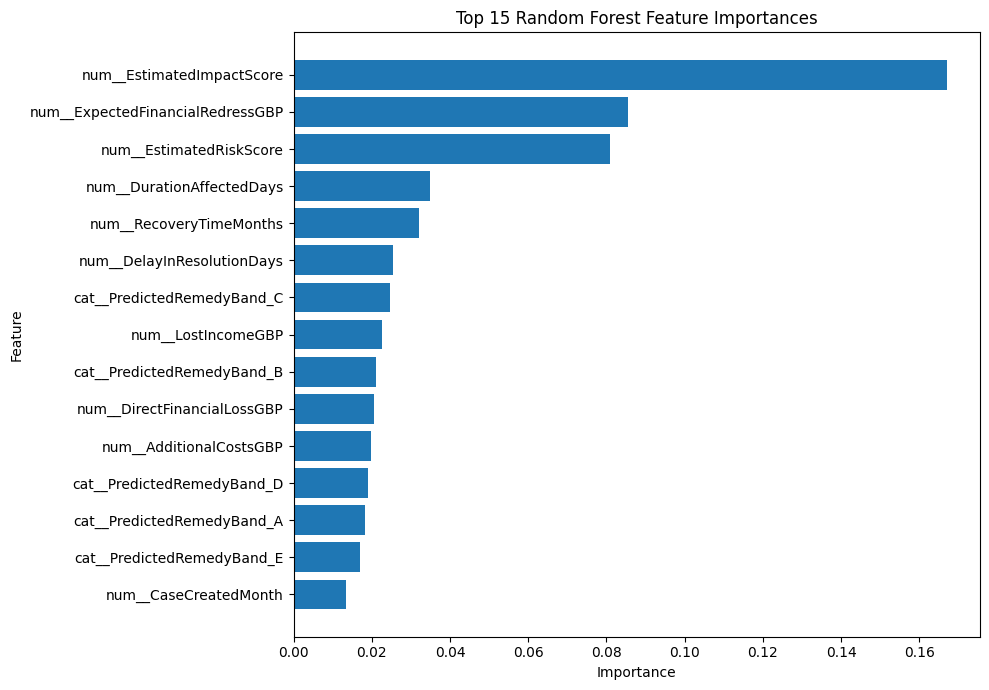

In [155]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [156]:
potential_features = [
    "EstimatedImpactScore",
    "EstimatedRiskScore",
    "ExpectedFinancialRedressGBP",
    "PredictedRemedyBand",
    "InvestigationRoute"
]

display(
    train[potential_features + ["SeverityScore"]]
    .head()
)

,EstimatedImpactScore,EstimatedRiskScore,ExpectedFinancialRedressGBP,PredictedRemedyBand,InvestigationRoute,SeverityScore
0,NaN,78,2120.15,C,Standard,3
1,48.0,34,1607.83,C,Standard,3
2,55.0,66,1640.46,C,Fast Track,3
3,29.0,15,261.30,B,Standard,1
4,30.0,60,337.50,B,Standard,2


In [157]:
train[potential_features + ["SeverityScore"]].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EstimatedImpactScore,1969.0,NaN,NaN,NaN,50.520061,24.733246,0.0,31.0,47.0,68.0,108.0
EstimatedRiskScore,2000.0,NaN,NaN,NaN,48.407,20.874655,-3.0,34.0,47.0,62.0,115.0
ExpectedFinancialRedressGBP,1944.0,NaN,NaN,NaN,1765.162855,3402.837423,-50.0,349.955,720.96,1926.945,90000.0
PredictedRemedyBand,2000,6,B,710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InvestigationRoute,2000,3,Standard,1434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeverityScore,2000.0,NaN,NaN,NaN,2.7535,1.484196,1.0,1.0,3.0,4.0,6.0


In [158]:
# Features that may represent downstream decisions or recommendations
potential_downstream_features = [
    "InvestigationRoute",
    "PredictedRemedyBand",
    "ExpectedFinancialRedressGBP"
]

X_conservative = X.drop(
    columns=potential_downstream_features,
    errors="ignore"
)

print("Original feature count:", X.shape[1])
print("Conservative feature count:", X_conservative.shape[1])

Original feature count: 45
Conservative feature count: 42


In [159]:
X_conservative_train = X_conservative.loc[X_train.index]
X_conservative_valid = X_conservative.loc[X_valid.index]

print("Conservative training:", X_conservative_train.shape)
print("Conservative validation:", X_conservative_valid.shape)

Conservative training: (1600, 42)
Conservative validation: (400, 42)


In [160]:
conservative_numeric_features = X_conservative_train.select_dtypes(
    include=["number"]
).columns.tolist()

conservative_categorical_features = X_conservative_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:", len(conservative_numeric_features))
print("Categorical features:", len(conservative_categorical_features))

Numeric features: 17
Categorical features: 25


In [161]:
conservative_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

conservative_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

conservative_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            conservative_numeric_transformer,
            conservative_numeric_features
        ),
        (
            "cat",
            conservative_categorical_transformer,
            conservative_categorical_features
        )
    ],
    remainder="drop"
)

In [162]:
conservative_rf = Pipeline(
    steps=[
        ("preprocessor", conservative_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

conservative_rf.fit(
    X_conservative_train,
    y_train
)

conservative_pred = conservative_rf.predict(
    X_conservative_valid
)

In [163]:
conservative_accuracy = accuracy_score(
    y_valid,
    conservative_pred
)

conservative_macro_f1 = f1_score(
    y_valid,
    conservative_pred,
    average="macro"
)

conservative_weighted_f1 = f1_score(
    y_valid,
    conservative_pred,
    average="weighted"
)

conservative_investigation_recall = recall_score(
    (y_valid >= 4).astype(int),
    (conservative_pred >= 4).astype(int)
)

print("Conservative Random Forest")
print("-------------------------")
print("Accuracy:", round(conservative_accuracy, 4))
print("Macro F1:", round(conservative_macro_f1, 4))
print("Weighted F1:", round(conservative_weighted_f1, 4))
print(
    "Investigation Recall:",
    round(conservative_investigation_recall, 4)
)

Conservative Random Forest
-------------------------
Accuracy: 0.73
Macro F1: 0.7302
Weighted F1: 0.7278
Investigation Recall: 0.825


In [164]:
pd.crosstab(
    train["PredictedRemedyBand"],
    train["SeverityScore"],
    normalize="index"
).round(2)

SeverityScore,1,2,3,4,5,6
PredictedRemedyBand,,,,,,
A,0.82,0.15,0.03,0.00,0.00,0.00
B,0.33,0.47,0.19,0.02,0.00,0.00
C,0.03,0.18,0.38,0.33,0.07,0.00
D,0.00,0.01,0.10,0.28,0.46,0.15
E,0.00,0.00,0.00,0.04,0.34,0.62
F,0.00,0.00,0.00,0.00,0.00,1.00


In [165]:
pd.crosstab(
    train["InvestigationRoute"],
    train["SeverityScore"],
    normalize="index"
).round(2)

SeverityScore,1,2,3,4,5,6
InvestigationRoute,,,,,,
Escalated,0.27,0.28,0.17,0.15,0.11,0.03
Fast Track,0.26,0.22,0.18,0.17,0.11,0.06
Standard,0.25,0.25,0.21,0.14,0.10,0.05


In [166]:
def evaluate_feature_set(X_data, feature_set_name):

    X_tr = X_data.loc[X_train.index]
    X_va = X_data.loc[X_valid.index]

    numeric_features = X_tr.select_dtypes(
        include=["number"]
    ).columns.tolist()

    categorical_features = X_tr.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )),
            ("encoder", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]
    )

    prep = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", prep),
            ("model", RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            ))
        ]
    )

    model.fit(X_tr, y_train)

    predictions = model.predict(X_va)

    accuracy = accuracy_score(y_valid, predictions)
    macro_f1 = f1_score(
        y_valid,
        predictions,
        average="macro"
    )
    weighted_f1 = f1_score(
        y_valid,
        predictions,
        average="weighted"
    )

    investigation_recall = recall_score(
        (y_valid >= 4).astype(int),
        (predictions >= 4).astype(int)
    )

    return {
        "Feature Set": feature_set_name,
        "Features": X_data.shape[1],
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Investigation Recall": investigation_recall
    }

In [167]:
results = []

# A. Full model
results.append(
    evaluate_feature_set(
        X,
        "Full feature set"
    )
)

# B. Remove PredictedRemedyBand
X_no_remedy = X.drop(
    columns=["PredictedRemedyBand"],
    errors="ignore"
)

results.append(
    evaluate_feature_set(
        X_no_remedy,
        "Without PredictedRemedyBand"
    )
)

# C. Remove ExpectedFinancialRedressGBP
X_no_redress = X.drop(
    columns=["ExpectedFinancialRedressGBP"],
    errors="ignore"
)

results.append(
    evaluate_feature_set(
        X_no_redress,
        "Without ExpectedFinancialRedressGBP"
    )
)

# D. Remove InvestigationRoute
X_no_route = X.drop(
    columns=["InvestigationRoute"],
    errors="ignore"
)

results.append(
    evaluate_feature_set(
        X_no_route,
        "Without InvestigationRoute"
    )
)

ablation_results = pd.DataFrame(results).round(4)

display(ablation_results)

,Feature Set,Features,Accuracy,Macro F1,Weighted F1,Investigation Recall
0,Full feature set,45,0.7750,0.7796,0.7730,0.9083
1,Without PredictedRemedyBand,44,0.7825,0.7812,0.7822,0.8583
2,Without ExpectedFinancialRedressGBP,44,0.7725,0.7827,0.7699,0.8917
3,Without InvestigationRoute,44,0.7625,0.7639,0.7599,0.9000


In [168]:
from sklearn.metrics import precision_score

rf_probabilities = random_forest_model.predict_proba(X_valid)

print("Probability matrix shape:", rf_probabilities.shape)
print("Classes:", random_forest_model.classes_)

Probability matrix shape: (400, 6)
Classes: [1 2 3 4 5 6]


In [169]:
classes = random_forest_model.classes_

investigation_probability = rf_probabilities[
    :,
    classes >= 4
].sum(axis=1)

print(
    "Example investigation probabilities:",
    investigation_probability[:10]
)

Example investigation probabilities: [0.         0.02333333 0.84       0.02333333 0.08666667 0.82666667
 0.41       0.06666667 0.01333333 0.30666667]


In [170]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

actual_investigation = (y_valid >= 4).astype(int)

for threshold in thresholds:

    predicted_investigation = (
        investigation_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            actual_investigation,
            predicted_investigation,
            zero_division=0
        ),
        "Recall": recall_score(
            actual_investigation,
            predicted_investigation,
            zero_division=0
        ),
        "F1": f1_score(
            actual_investigation,
            predicted_investigation,
            zero_division=0
        ),
        "Cases Progressed": predicted_investigation.sum()
    })

threshold_results = pd.DataFrame(threshold_results).round(4)

display(threshold_results)

,Threshold,Precision,Recall,F1,Cases Progressed
0,0.30,0.8014,0.9750,0.8797,146
1,0.35,0.8582,0.9583,0.9055,134
2,0.40,0.8779,0.9583,0.9163,131
3,0.45,0.8968,0.9417,0.9187,126
4,0.50,0.9237,0.9083,0.9160,118
5,0.55,0.9364,0.8583,0.8957,110
6,0.60,0.9412,0.8000,0.8649,102
7,0.65,0.9579,0.7583,0.8465,95
8,0.70,1.0000,0.6833,0.8119,82


#### Investigation Decision Threshold

The operational objective is not limited to predicting the exact SeverityScore.
Cases with SeverityScore 4–6 require further investigation, so the model's
probability of belonging to this group was evaluated separately.

Rather than using the default 0.50 threshold, several thresholds were tested
on the validation set.

A threshold of 0.40 was selected because it provides a strong balance between
precision and recall while prioritising the identification of cases requiring
further investigation.

At this threshold:

- Precision: 87.79%
- Recall: 95.83%
- F1: 91.63%
- Cases progressed: 131 of 400

The threshold captures 115 of the 120 validation cases requiring investigation,
while accepting some additional false positives. This is appropriate for the
operational context because the cost of missing a higher-severity case is
greater than progressing an additional case for review.

### **Holdback Prediction**

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [172]:
# train was previously created from training_df
# holdback was previously created from holdback_df

final_train = train.copy()
final_holdback = holdback.copy()

print("\nDataset sizes")
print("-" * 70)
print("Training data:", final_train.shape)
print("Holdback data:", final_holdback.shape)


Dataset sizes
----------------------------------------------------------------------
Training data: (2000, 48)
Holdback data: (500, 47)


In [173]:
TARGET = "SeverityScore"

y_final = final_train[TARGET].copy()

X_final = final_train.drop(
    columns=[TARGET],
    errors="ignore"
).copy()

X_holdback = final_holdback.copy()

In [174]:
# These columns should not be used as predictive features.
# Keep CaseReference separately so it can be included in
# the final prediction output.

identifier_columns = [
    "CaseReference",
    "OmbudsmanInvestigationRequired"
]

case_references = (
    X_holdback["CaseReference"].copy()
    if "CaseReference" in X_holdback.columns
    else pd.Series(
        np.arange(len(X_holdback)),
        name="CaseReference"
    )
)

X_final = X_final.drop(
    columns=identifier_columns,
    errors="ignore"
)

X_holdback = X_holdback.drop(
    columns=identifier_columns,
    errors="ignore"
)

In [175]:
# The holdback set should contain the same predictor columns
# as the training set.

missing_from_holdback = [
    col for col in X_final.columns
    if col not in X_holdback.columns
]

extra_in_holdback = [
    col for col in X_holdback.columns
    if col not in X_final.columns
]

print("\nFeature consistency check")
print("-" * 70)
print("Training features:", X_final.shape[1])
print("Holdback features:", X_holdback.shape[1])
print("Missing from holdback:", missing_from_holdback)
print("Extra in holdback:", extra_in_holdback)


# If there are unexpected extra columns in holdback,
# remove them so the model receives exactly the training features.

X_holdback = X_holdback.drop(
    columns=extra_in_holdback,
    errors="ignore"
)

# Reorder holdback columns to exactly match training columns.

X_holdback = X_holdback[X_final.columns]


print("\nAfter alignment")
print("Training features:", X_final.shape[1])
print("Holdback features:", X_holdback.shape[1])
print(
    "Feature order identical:",
    list(X_final.columns) == list(X_holdback.columns)
)


Feature consistency check
----------------------------------------------------------------------
Training features: 45
Holdback features: 45
Missing from holdback: []
Extra in holdback: []

After alignment
Training features: 45
Holdback features: 45
Feature order identical: True


In [176]:
numeric_features = X_final.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_final.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nFeature types")
print("-" * 70)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))



Feature types
----------------------------------------------------------------------
Numeric features: 18
Categorical features: 27


In [177]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)


In [178]:

# These are the ORIGINAL Random Forest settings that gave us
# the strongest overall validation performance.

final_random_forest = Pipeline(
    steps=[
        (
            "preprocessor",
            final_preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)



In [179]:
print("\nTraining final Random Forest...")
print("-" * 70)

final_random_forest.fit(
    X_final,
    y_final
)

print("Final model training complete.")


Training final Random Forest...
----------------------------------------------------------------------
Final model training complete.


In [180]:
holdback_severity_prediction = (
    final_random_forest.predict(X_holdback)
)


In [181]:
holdback_probabilities = (
    final_random_forest.predict_proba(X_holdback)
)

model_classes = final_random_forest.classes_

print("\nModel classes:")
print(model_classes)

print(
    "Probability matrix shape:",
    holdback_probabilities.shape
)


Model classes:
[1 2 3 4 5 6]
Probability matrix shape: (500, 6)


In [182]:
# Business rule:
#
# Severity 4, 5 and 6 = cases requiring further investigation
#
# Fixed threshold selected using validation data:
#
# P(Severity 4-6) >= 0.40
#     -> Progress to investigation
#
# P(Severity 4-6) < 0.40
#     -> Do not progress automatically

investigation_class_mask = model_classes >= 4

investigation_probability = (
    holdback_probabilities[:, investigation_class_mask]
    .sum(axis=1)
)

INVESTIGATION_THRESHOLD = 0.40

investigation_decision = np.where(
    investigation_probability >= INVESTIGATION_THRESHOLD,
    "Progressed",
    "Not Progressed"
)


Final Prediction DataFrame

In [183]:
holdback_predictions = pd.DataFrame({
    "CaseReference": case_references.values,
    "PredictedSeverityScore": holdback_severity_prediction,
    "InvestigationProbability": investigation_probability,
    "InvestigationDecision": investigation_decision
})

In [184]:
for i, class_label in enumerate(model_classes):

    holdback_predictions[
        f"Probability_Severity_{class_label}"
    ] = holdback_probabilities[:, i]


In [185]:
probability_columns = [
    col
    for col in holdback_predictions.columns
    if "Probability" in col
]

holdback_predictions[probability_columns] = (
    holdback_predictions[probability_columns]
    .round(4)
)


In [186]:
print("\n" + "=" * 70)
print("HOLDBACK PREDICTION QA")
print("=" * 70)

print(
    "\nNumber of holdback cases:",
    len(holdback_predictions)
)

print(
    "Expected holdback cases:",
    len(final_holdback)
)

print(
    "Number of predictions:",
    len(holdback_predictions)
)

print(
    "Unique CaseReferences:",
    holdback_predictions["CaseReference"].nunique()
)

print(
    "Missing severity predictions:",
    holdback_predictions["PredictedSeverityScore"].isna().sum()
)

print(
    "Missing investigation probabilities:",
    holdback_predictions["InvestigationProbability"].isna().sum()
)

print(
    "Missing investigation decisions:",
    holdback_predictions["InvestigationDecision"].isna().sum()
)


HOLDBACK PREDICTION QA

Number of holdback cases: 500
Expected holdback cases: 500
Number of predictions: 500
Unique CaseReferences: 500
Missing severity predictions: 0
Missing investigation probabilities: 0
Missing investigation decisions: 0


In [187]:
valid_severity_classes = {1, 2, 3, 4, 5, 6}

invalid_predictions = (
    ~holdback_predictions["PredictedSeverityScore"]
    .isin(valid_severity_classes)
).sum()

print(
    "Invalid severity predictions:",
    invalid_predictions
)

Invalid severity predictions: 0


In [188]:
print(
    "\nInvestigation probability range:",
    round(
        holdback_predictions["InvestigationProbability"].min(),
        4
    ),
    "to",
    round(
        holdback_predictions["InvestigationProbability"].max(),
        4
    )
)


Investigation probability range: 0.0 to 0.9933


In [189]:
severity_probability_columns = [
    f"Probability_Severity_{class_label}"
    for class_label in model_classes
]

probability_sum = (
    holdback_predictions[
        severity_probability_columns
    ].sum(axis=1)
)

max_probability_error = np.abs(
    probability_sum - 1
).max()

print(
    "Maximum probability sum error:",
    max_probability_error
)

Maximum probability sum error: 0.00019999999999975593


In [190]:
print("\nInvestigation decision distribution")
print("-" * 70)

decision_counts = (
    holdback_predictions[
        "InvestigationDecision"
    ]
    .value_counts()
)

print(decision_counts)

print("\nInvestigation decision percentages")
print("-" * 70)

print(
    (
        holdback_predictions[
            "InvestigationDecision"
        ]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
)


Investigation decision distribution
----------------------------------------------------------------------
InvestigationDecision
Not Progressed    340
Progressed        160
Name: count, dtype: int64

Investigation decision percentages
----------------------------------------------------------------------
InvestigationDecision
Not Progressed    68.0
Progressed        32.0
Name: proportion, dtype: float64


In [191]:
print("\nPredicted SeverityScore distribution")
print("-" * 70)

severity_distribution = (
    holdback_predictions[
        "PredictedSeverityScore"
    ]
    .value_counts()
    .sort_index()
)

print(severity_distribution)

print("\nPredicted SeverityScore percentages")
print("-" * 70)

print(
    (
        holdback_predictions[
            "PredictedSeverityScore"
        ]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
)



Predicted SeverityScore distribution
----------------------------------------------------------------------
PredictedSeverityScore
1    142
2    113
3     96
4     77
5     51
6     21
Name: count, dtype: int64

Predicted SeverityScore percentages
----------------------------------------------------------------------
PredictedSeverityScore
1    28.4
2    22.6
3    19.2
4    15.4
5    10.2
6     4.2
Name: proportion, dtype: float64


In [192]:
print("\nFirst 20 holdback predictions")
print("=" * 70)

display(
    holdback_predictions.head(20)
)


First 20 holdback predictions


,CaseReference,PredictedSeverityScore,InvestigationProbability,InvestigationDecision,Probability_Severity_1,Probability_Severity_2,Probability_Severity_3,Probability_Severity_4,Probability_Severity_5,Probability_Severity_6
0,HLD-000001,5,0.8400,Progressed,0.0033,0.0600,0.0967,0.2900,0.3333,0.2167
1,HLD-000002,4,0.8733,Progressed,0.0067,0.0300,0.0900,0.4500,0.3600,0.0633
2,HLD-000003,1,0.0033,Not Progressed,0.8333,0.1200,0.0433,0.0033,0.0000,0.0000
3,HLD-000004,3,0.3533,Not Progressed,0.0167,0.1767,0.4533,0.2800,0.0667,0.0067
4,HLD-000005,4,0.7900,Progressed,0.0033,0.0367,0.1700,0.6433,0.1267,0.0200
5,HLD-000006,2,0.0267,Not Progressed,0.3367,0.4933,0.1433,0.0233,0.0000,0.0033
6,HLD-000007,1,0.0100,Not Progressed,0.7133,0.2600,0.0167,0.0067,0.0033,0.0000
7,HLD-000008,3,0.1300,Not Progressed,0.0267,0.2567,0.5867,0.1100,0.0200,0.0000
8,HLD-000009,1,0.0100,Not Progressed,0.7600,0.1967,0.0333,0.0033,0.0067,0.0000
9,HLD-000010,5,0.9100,Progressed,0.0033,0.0233,0.0633,0.2633,0.3567,0.2900


In [193]:
prediction_file = (
    "phso_holdback_predictions.csv"
)

holdback_predictions.to_csv(
    prediction_file,
    index=False
)

print(
    "\nSaved predictions to:",
    prediction_file
)


Saved predictions to: phso_holdback_predictions.csv


In [194]:
model_file = (
    "phso_final_random_forest.joblib"
)

joblib.dump(
    final_random_forest,
    model_file
)

print(
    "Saved final model to:",
    model_file
)

Saved final model to: phso_final_random_forest.joblib


In [195]:
feature_metadata = pd.DataFrame({
    "Feature": X_final.columns,
    "DataType": [
        X_final[col].dtype
        for col in X_final.columns
    ]
})

feature_metadata.to_csv(
    "phso_final_model_features.csv",
    index=False
)

print(
    "Saved feature list to:",
    "phso_final_model_features.csv"
)

Saved feature list to: phso_final_model_features.csv


In [196]:
print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print("Training cases:", len(X_final))
print("Holdback cases:", len(X_holdback))
print("Number of features:", X_final.shape[1])
print("Model: Random Forest")
print("n_estimators: 300")
print("class_weight: balanced")
print("Investigation threshold:", INVESTIGATION_THRESHOLD)

print("\nOutput files:")
print("1.", prediction_file)
print("2.", model_file)
print("3.", "phso_final_model_features.csv")

print("\nFinal holdback prediction process complete.")


FINAL MODEL SUMMARY
Training cases: 2000
Holdback cases: 500
Number of features: 45
Model: Random Forest
n_estimators: 300
class_weight: balanced
Investigation threshold: 0.4

Output files:
1. phso_holdback_predictions.csv
2. phso_final_random_forest.joblib
3. phso_final_model_features.csv

Final holdback prediction process complete.


### **Submisson**

In [197]:
phso_submission = holdback_predictions[
    ["CaseReference", "PredictedSeverityScore"]
].copy()

In [198]:
print("=" * 70)
print("PHSO OFFICIAL SUBMISSION FILE QA")
print("=" * 70)

print(f"Number of rows: {len(phso_submission)}")
print(f"Expected rows: 500")

print(f"\nColumns:")
print(phso_submission.columns.tolist())

print(f"\nMissing CaseReference: "
      f"{phso_submission['CaseReference'].isna().sum()}")

print(f"Missing PredictedSeverityScore: "
      f"{phso_submission['PredictedSeverityScore'].isna().sum()}")

print(f"Unique CaseReferences: "
      f"{phso_submission['CaseReference'].nunique()}")

print(f"\nValid severity values:")
print(
    phso_submission["PredictedSeverityScore"]
    .isin([1, 2, 3, 4, 5, 6])
    .all()
)

print("\nPredicted severity distribution:")
print(
    phso_submission["PredictedSeverityScore"]
    .value_counts()
    .sort_index()
)

PHSO OFFICIAL SUBMISSION FILE QA
Number of rows: 500
Expected rows: 500

Columns:
['CaseReference', 'PredictedSeverityScore']

Missing CaseReference: 0
Missing PredictedSeverityScore: 0
Unique CaseReferences: 500

Valid severity values:
True

Predicted severity distribution:
PredictedSeverityScore
1    142
2    113
3     96
4     77
5     51
6     21
Name: count, dtype: int64


In [199]:
assert len(phso_submission) == 500
assert phso_submission.columns.tolist() == [
    "CaseReference",
    "PredictedSeverityScore"
]
assert phso_submission["CaseReference"].notna().all()
assert phso_submission["PredictedSeverityScore"].notna().all()
assert phso_submission["CaseReference"].nunique() == 500
assert phso_submission["PredictedSeverityScore"].isin(
    [1, 2, 3, 4, 5, 6]
).all()


In [200]:
submission_path = "/content/phso_predictions.csv"

phso_submission.to_csv(
    submission_path,
    index=False
)

print("\n" + "=" * 70)
print("OFFICIAL SUBMISSION FILE CREATED")
print("=" * 70)

print(f"Saved to: {submission_path}")

print("\nFirst 20 rows:")
display(phso_submission.head(20))

print("\nFile contents:")
print(phso_submission.to_csv(index=False)[:1000])


OFFICIAL SUBMISSION FILE CREATED
Saved to: /content/phso_predictions.csv

First 20 rows:


,CaseReference,PredictedSeverityScore
0,HLD-000001,5
1,HLD-000002,4
2,HLD-000003,1
3,HLD-000004,3
4,HLD-000005,4
5,HLD-000006,2
6,HLD-000007,1
7,HLD-000008,3
8,HLD-000009,1
9,HLD-000010,5



File contents:
CaseReference,PredictedSeverityScore
HLD-000001,5
HLD-000002,4
HLD-000003,1
HLD-000004,3
HLD-000005,4
HLD-000006,2
HLD-000007,1
HLD-000008,3
HLD-000009,1
HLD-000010,5
HLD-000011,3
HLD-000012,2
HLD-000013,4
HLD-000014,1
HLD-000015,1
HLD-000016,2
HLD-000017,4
HLD-000018,2
HLD-000019,1
HLD-000020,3
HLD-000021,4
HLD-000022,4
HLD-000023,3
HLD-000024,4
HLD-000025,1
HLD-000026,3
HLD-000027,4
HLD-000028,1
HLD-000029,1
HLD-000030,3
HLD-000031,2
HLD-000032,1
HLD-000033,1
HLD-000034,2
HLD-000035,4
HLD-000036,2
HLD-000037,3
HLD-000038,2
HLD-000039,4
HLD-000040,2
HLD-000041,4
HLD-000042,2
HLD-000043,2
HLD-000044,2
HLD-000045,4
HLD-000046,2
HLD-000047,1
HLD-000048,6
HLD-000049,2
HLD-000050,2
HLD-000051,3
HLD-000052,4
HLD-000053,5
HLD-000054,4
HLD-000055,4
HLD-000056,3
HLD-000057,2
HLD-000058,5
HLD-000059,2
HLD-000060,4
HLD-000061,6
HLD-000062,2
HLD-000063,2
HLD-000064,5
HLD-000065,1
HLD-000066,1
HLD-000067,2
HLD-000068,2
HLD-000069,6
HLD-000070,2
HLD-000071,5
HLD-000072,6
HLD-000073,